## Prompting and Prompt Engineering

### Introduction


There are various ways we can use the model to perform the task we are planning to do. The first could be to train our own model from scratch. For this, at first, we have to collect a lot of data that matches our use case, then have the powerful resources to be able to train the model. This is one of the time-consuming and costly approaches.

The other option is to use the existing model (usually the foundation model) that is already trained and made available to us by big companies spending a lot of human resources, time and money. These base models may not perform best for our particular use case. So, we have to adapt and align the model according to our needs.

Prompting is one of the ways by which we can make models adapt to our use-cases. Larger the model size, larger the parameters associated with the model and more is the ability of that model to understand the complex patterns of the language. Larger models have wide domain knowledge with very high generalization ability since they are trained on a huge dataset. So, larger models are easy to prompt and make them behave and respond in a certain way as per our necessity. Small models can also perform well when they are provided with a few examples in a prompt itself with the newly emerged concept called in-context learning. There are various prompting techniques by which we can guide the response of the language model according to how we want them to think and behave.

If the prompting is maxed out, which means the task is so complex and unique that the prompts are not being able to handle effectively, then we have to opt for the next option of fine tuning the base foundational model. During fine tuning, we take the base model and train the model using the high quality dataset (usually labeled) that meets our use case. This way, the model with the higher level of understanding of language can be easily made to fit our needs with comparatively less resources and in a short time.

In this chapter, we are going to talk about prompting and the various techniques of prompting. We will also cover prompt engineering and conditions where the prompting might fail.


### Prompting

Prompting is the process of using prompts as input to elicit the desired response or output from the language model. It is the way of instructing the model crafting the prompt with the intention to steer the generated response in the right direction. Prompting is often used to gather information and generate specific types of responses from the language model.

Prompt Engineering refers to the process of designing and using structured prompts employing various techniques such as one-shot and few-shot learning to improve the responses. The goal of prompt engineering is to optimize the quality of prompt and guide the output from a model identifying the areas of improvement. This is highly experimental as we have to study the capabilities and limitations of LLM by trial and error with the motive of designing a good prompt that LLM can comprehend. Restricting prompts based on user roles, controlling output length to manage computational costs, data integrity and security, etc all fall under the scope of Prompt Engineering.

Prompting and Prompt Engineering involves use of prompts but they differ in their intent and application. Prompt development is an iterative process. One can never come to the production ready prompt at a single shot. It has to be tried iteratively making the prompt better each time.


#### Prompt Designing


Writing a good prompt is just like making a google search with the necessary keywords to use search engines to get the relevant results we want. The quality of the model's output largely depends on the quality of the prompt. So, it is necessary to design and structure the prompt to generate the relevant response.

Prompt Designing involves formulating clear, effective instructions that can guide language models to generate accurate and relevant responses avoiding biases or misleading information from models. This mainly covers the area of providing enough details, employing appropriate tone and understanding the nuances of a language model. Using appropriate strategies, which include establishing proper context, supplying ample detail, and applying a suitable tone, can collectively result in a substantial improvement in the quality and relevance of the model's outputs.

Below is the list of elements that should be included in the prompt as required by the use case in order to structure the prompt and get the optimal result.  
- Role
- Instruction
- Input
- Examples
- Context
- Question


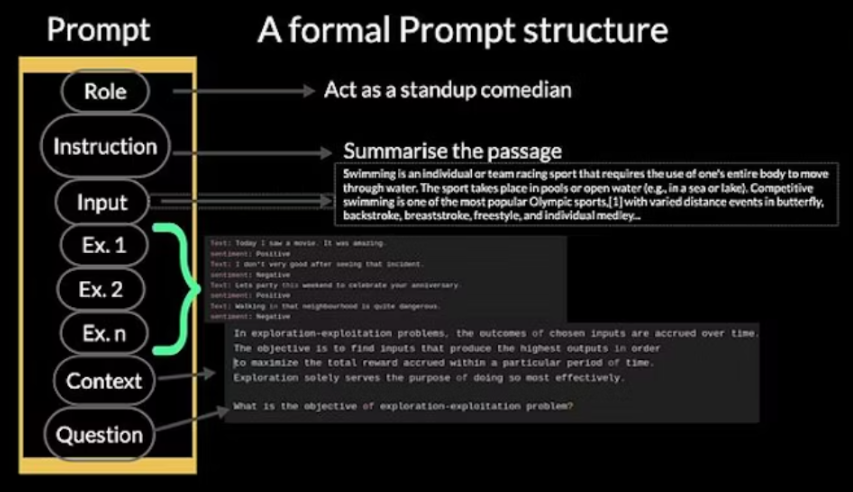

#### Prompting Strategies/Guidelines


1. Set a specific goal defining the role the language model has to do.
2. Write clear and specific instructions constraining the scope of the problem.
3. Explicitly mention the format of the output.
4. Provide the context to the query if the problem requires.
5. Break down the bigger task into smaller tasks and make LLM do logical reasoning using Chain-of-thought alike prompting techniques.
6. Providing examples for few shot learning
7. Explicitly mention where the certain content is in the prompt using the help of triple quotations, or any other special characters.


### Generative Configuration


There are various settings we can experiment to influence the structure and style of completion the model generates (next word generation).

#### Greedy vs random sampling


The output from the transformers softmax layer is a probability distribution across the entire dictionary of words the model uses. Below only four words are shown and this is the table with the list of all dictionaries.

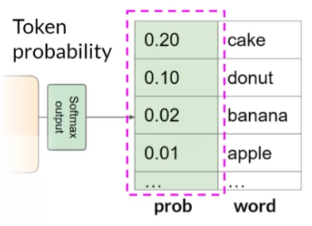

##### Greedy Sampling




Most of the language model works with greedy decoding. In this sampling, the model will always predict the next word/token with the highest probability.

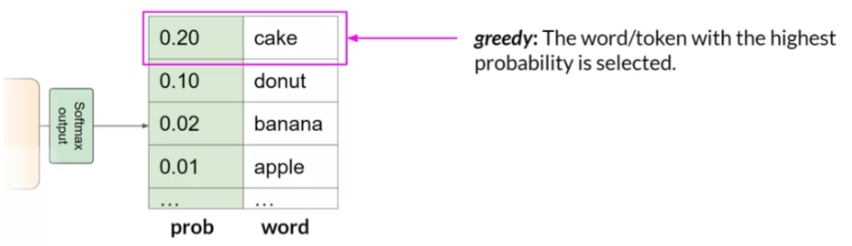

Greedy sampling is susceptible to repeated words/sequence of words. If we want to generate a text that's more creative and natural and avoid repeating words, we need to use random sampling. It introduces some variability.

#### Random Sampling

In random sampling, a token is selected using a random-weighted strategy across the probabilities of all tokens. With random sampling, the model chooses the words at random using the probability distribution to weight the selection.

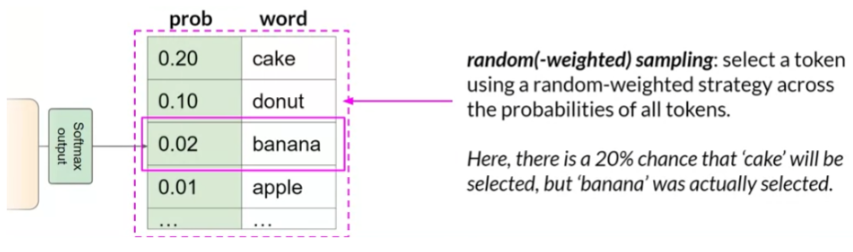

There is a 20% chance that ‘cake’ will be selected and 2% chance that the word ‘banana’ will be selected. Top-k and Top-p further limit the random sampling to make the output more sensible allowing variability.

### Configuration Parameters

Below mentioned configuration parameters are invoked at inference time and gives us control over things like maximum number of token generation and how creative output is. They all operate on the probability distribution that is output by the LLM.

#### Top-k

It instructs model to choose from only k tokens with highest probability


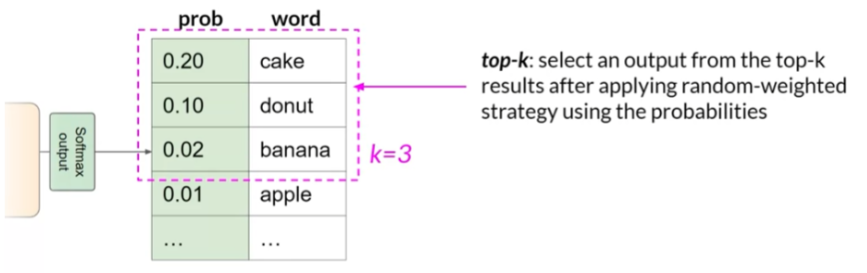

In the above example, the model selects only from the top-3 tokens using the probability weighting. This method enables randomness while preventing the selection of highly improbable completion words that are irrelevant.

For example, we had a vocabulary of size 5, then the outputs could be as follows.
$$ t_0 → 0.3 $$
$$ t_1  → 0.2 $$
$$ t_2 → 0.2 $$
$$ t_3 → 0.15 $$
$$ t_4 → 0.05 $$

Then, if we sample using top-3 strategy from above example, top-3 tokens will be:
$$ t_0 → 0.3 $$
$$ t_1 → 0.2 $$
$$ t_2 → 0.2 $$

However, the probabilities don't add up to 1. So, we normalize the probability and divide each by 0.3+0.2+0.2 = 0.7. And we get the following.
$$ t_0 → 0.42 $$
$$ t_1 → 0.29 $$
$$ t_2 → 0.29 $$

Now, we select a token by sampling from it based on the weightage of the probability.


#### Top-p

It instructs the model to choose from the top token whose probability adds up to the value of p. This setting limits the random sampling to the predictions whose combined probabilities do not exceed the value of p. This strategy is also called nucleus sampling.

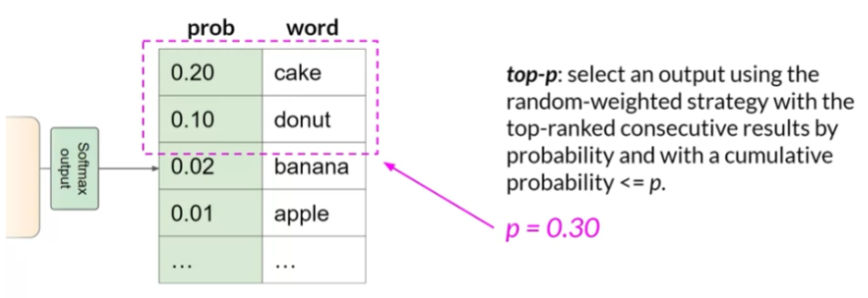

In the above example, the combined probability of ‘cake’ and ‘donut’ add up to the value equal to p=0.3. So, at the time of random sampling, the model uses the random probability weighting to choose from the tokens ‘cake’ and ‘donut’.

For example, if we sample with top p strategy using p=0.4. Then, the first is selected which makes the cumulative probability to be 0.3 which is less than required 0.4. So, the next token with probability of 0.2 is selected which makes cumulative probability to be 0.5, which is at least the value of p = 0.4. Hence, the top-2 tokens are selected.
$$ t_0 → 0.3 $$
$$ t_1 → 0.2 $$

Now, we normalize this value to 1 and make a sampling just like in top-k.

Hence, with top-k we specify the top tokens to choose from and with top-p we specify the total probability we want the model to choose from. It is recommended to use only one of these two parameters.


#### Temperature

While Top-k and Top-p operate directly on the output probabilities, temperature affects the softmax function itself. Temperature influences the shape of probability distribution the model calculates for the next token. It is applied in the final softmax layer and directly alters the prediction of probability the model makes.

The softmax function takes in a vector of n real numbers, and then normalizes it into a discrete probability distribution across those n elements whose probabilities will sum to 1.

$$  \sigma (x)_i = \frac{e^{x_i}}{\sum_{j=1}^{n}{e^{x_j}}} $$

Temperature is the parameter of the softmax function, which is the last layer in the network. This value affects whether the difference between input values is to be amplified or reduced.

$$ \sigma (x)_i = \frac{e^{\frac{x_i}{T}}}{\sum_{j=1}^{n} e^{\frac{x_j}{T}}} $$

If 0<T<1, then the $x_i$ input values get pushed further away from 0 and differences are amplified.
If T>1, then the $x_i$ input values get pushed toward 0 and differences are reduced.

Higher the temperature, higher the randomness and vice versa.


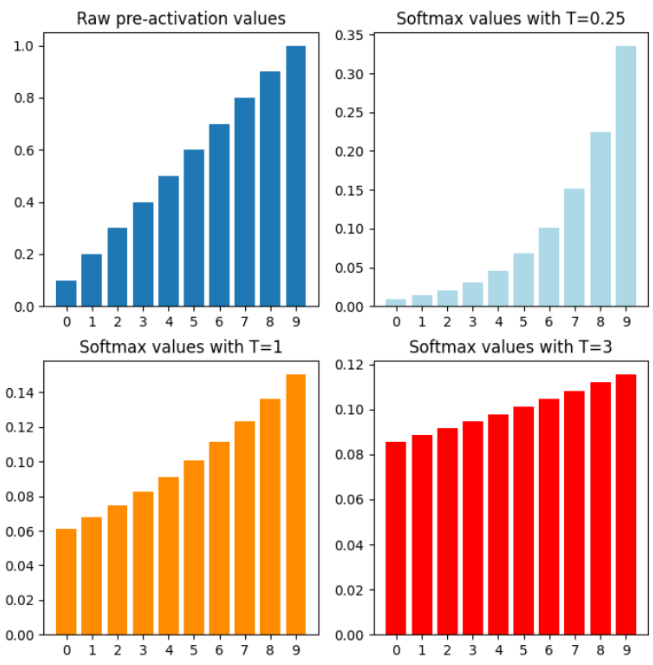

When the higher temperature is selected, the model calculates the broader flatter probability distribution for the next token. The probabilities are evenly spread across the tokens which leads the model to generate the text with higher degree of randomness.



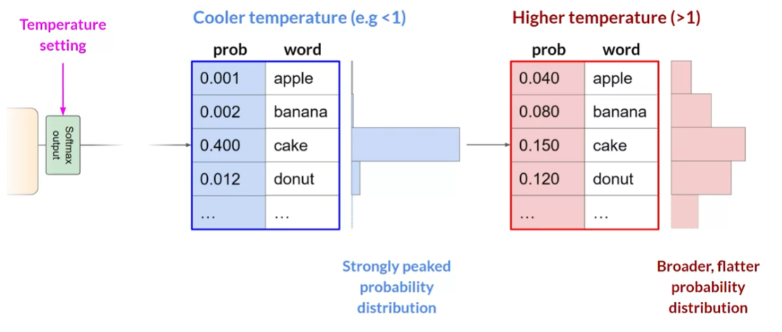

If the temperature=1 is used, this leads to the softmax function as default and unaltered probability distribution is used.


#### Max_new_tokens

It is the maximum number of tokens generated by the language model. There is a token limit determined by the architecture of the language model. Token limit is the maximum number of tokens that can be used in the prompt and the completion of the model i.e. maximum tokens that can be processed at once.

The computational cost and memory needs increase as you raise the max tokens. A longer max token provides more context and coherent output, while a shorter one reduces memory usage and speeds up responses but may lead to errors and inconsistencies.


#### Stop_sequence/token


The special symbol or sequence of characters used to indicate the end of a sequence or sentence is a stop sequence. If the model produces the stop token even before reaching the max_new_token limit, the generation is terminated.

### Prompting Techniques

#### Zero Shot Prompting


In this technique of prompting, we feed in the prompt to the model and directly get the required relevant response from the language model. We don't provide any examples or context in the prompt. It is also known as Input Output Prompting as output is directly generated without any aid of examples and context for the given input. Instruction tuned models show greater performance in zero-shot learning. (usually base foundational models are trained on dataset described via instructions)

For example: \\
Prompt: \\
Classify the text into neutral, negative or positive.

Text: I think the food was okay. \\
Sentiment:

Output: \\
Neutral


#### Few Shot Prompting


Although Large-language models are significantly good in their zero-shot capabilities, they may lag behind on complex tasks.
Few shot prompting is a technique in which we feed in a few examples in the prompts to steer the model to perform better.
This technique learns to perform specific tasks using a technique called in-context learning.
The format of the examples in the prompt can be made consistent for the better response.

For example: \\
Prompt: \\
This is awesome! // Negative \\
This is bad! // Positive \\
Wow that movie was rad! // Positive \\
What a horrible show! //

Output: \\
Negative

**Limitation:** \\
Few-shot prompts work well for many tasks, but they still fail when dealing with complex reasoning tasks that require a few more reasoning steps. (need to break down the problem into steps)


#### Chain-of-Thoughts (CoT)


This prompting technique enables the complex reasoning capabilities through intermediate reasoning steps.  In this technique, the problem is broken down into several steps that can be achieved using zero-shot (for relatively simple tasks) or few-shot (for more complex tasks) to get better results.

In zero-shot CoT, we can simply guide the model to make logical reasoning steps from the prompt.

For example: \\
Let’s think step by step. \\
Think carefully and logically, explaining your answer. \\

In a few-shot CoT, we provide the example explicitly showing how to reason in the intermediate steps. \\

For example: \\
Prompt: \\
The odd numbers in this group add up to an even number: 4, 8, 9, 15, 12, 2, 1. \\
A: Adding all the odd numbers (9, 15, 1) gives 25. The answer is False. \\
The odd numbers in this group add up to an even number: 17,  10, 19, 4, 8, 12, 24. \\
A: Adding all the odd numbers (17, 19) gives 36. The answer is True. \\
The odd numbers in this group add up to an even number: 15, 32, 5, 13, 82, 7, 1. \\
A: \\

Output: \\
Adding all the odd numbers (15, 5, 13, 7, 1) gives 41. The answer is False.

The figure below shows the difference in using the chain-of-thought and not using it for the reasoning tasks.


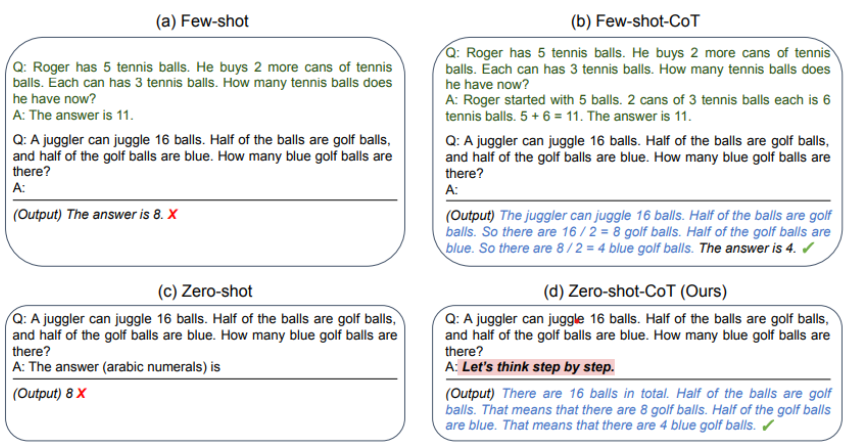

Figure 1: Example inputs and outputs of GPT-3 with (a) standard Few-shot, (b)Few-shot-CoT, (c) standard Zero-shot, and (d) ours (Zero-shot-CoT). Similar to Few-shot-CoT, Zero-shot-CoT facilitates multi-step reasoning (blue text) and reaches the correct answer where standard prompting fails. Unlike Few-shot-CoT using step-by-step reasoning examples per task, ours does not need any examples and just uses the same prompt “Let’s think step by step” across all tasks (arithmetic, symbolic, commonsense, and other logical reasoning tasks).

#### Self-Consistency


In this technique, Language models generate a diverse set of reasoning paths, then based on the majority votes of answer, a consistent response is generated.
This is a further improvement in the chain-of-thought prompting which replaces the naive greedy decoding used in CoT.
Limitation: this technique has more computation cost as multiple diverse reasoning paths are sampled to select the final answer.


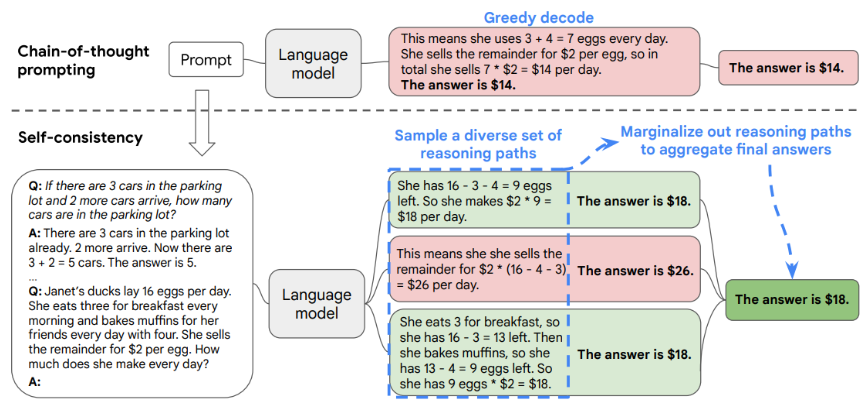

Figure: The self-consistency method contains three steps: (1) prompt a language model using chain-of-thought (CoT) prompting; (2) replace the “greedy decode” in CoT prompting by sampling from the language model’s decoder to generate a diverse set of reasoning paths; and (3) marginalize out the reasoning paths and aggregate by choosing the most consistent answer in the final answer set.

#### Tree-of-Thoughts

This prompting technique is mainly used for complex tasks that require exploration or strategic lookahead.
This technique generalizes over Chain-of-thought and supports exploration over thoughts that serve as intermediate steps.
enables a LM to explore multiple branches of reasoning while self-evaluating the intermediate progress and then combined with search algorithms (breadth-first search and depth-first search) to enable systematic exploration with lookahead and backtracking.
This technique is illustrated by using the Game of 24 task.

Rule: You are given four numbers. You have to get 24 but you can use the number only once and can use the results too. There can be multiple solutions. Has three steps to reach a solution.


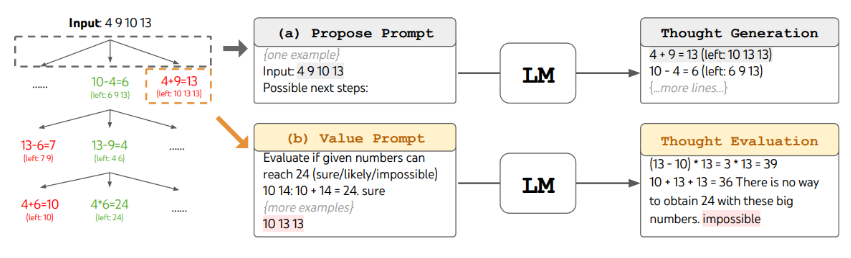

#### ReAct

ReAct is the abbreviation of Reasoning and Acting.
In this prompt technique, generation of both reasoning and task-specific actions is performed in an interleaved manner. i.e. synergize reasoning and acting in a language model
Reasoning helps the model to induce, track and update action plans as well as handle exceptions, while actions allow it to interface with and gather additional information from external sources of knowledge base.
Unlike Chain-of-Thought (CoT), ReAct overcomes issues of hallucination and error propagation by interacting with external knowledge sources.


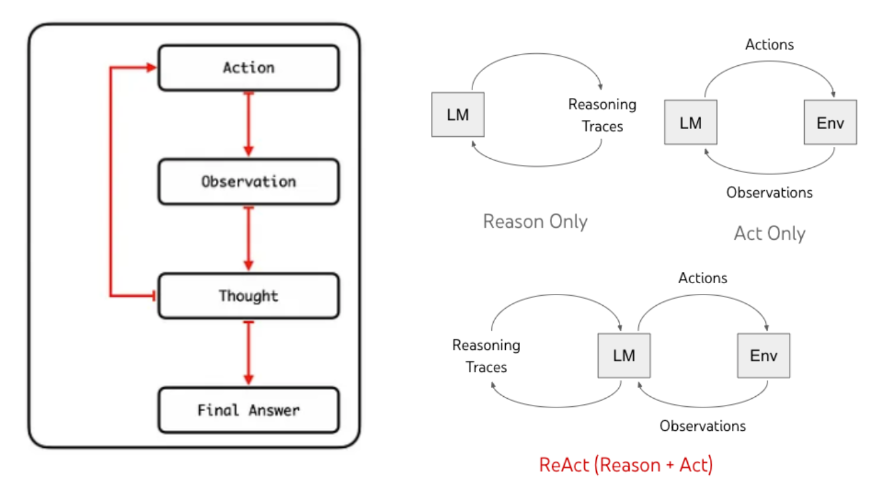

Figure: Working of ReAct prompting (left), Flow of various prompting techniques reason only, act only and reason + act (right)

The ReAct prompt includes thoughts, actions and observations. The thought and actions are continuously run until a stopping criteria is met. The stopping criteria could be hardcoded rules (e.g. stop after 3 iterations) or LLM determined (LLM thinks the final answer is achieved).

Steps: \\
- Input query is received from the user
- The agent decides the tool and what type of tool is required to perform actions
- That tool is called with input tool and observation is recorded
- Based on the observation, LLM generates a thought which is further used to reason which action to take next
- Repeat the process until the agent decides to quit

This ReAct prompting serves as the logic behind how the action agents work.

Below is an example of a question taken from HotpotQA dataset. These are the questions that searches Wikipedia and multi-hops are required to answer.


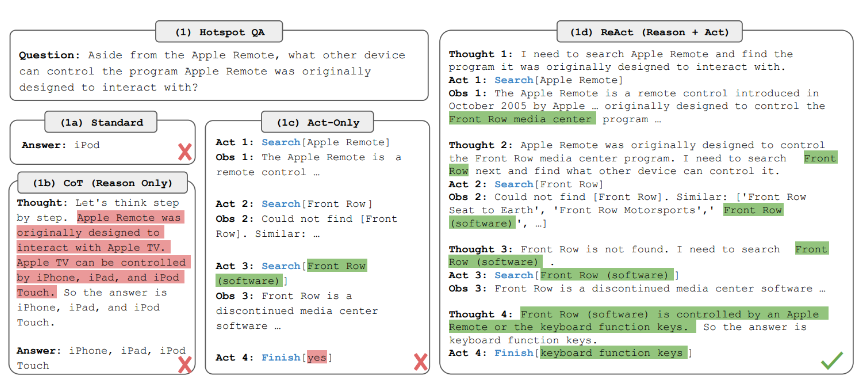

Figure: (1) Comparison of 4 prompting methods, (a) Standard, (b) Chain-of-thought (CoT, Reason Only), (c) Act-only, and (d) ReAct (Reason+Act), solving a HotpotQA question.

Limitation of ReAct:
The structural constraint of ReAct reduces its flexibility in formulating reasoning steps.
ReAct depends a lot on the information it’s retrieving so if the search results are non-informative, it takes thoughts out of track.

Prompting methods that combine and support switching between ReAct and CoT+Self-Consistency generally outperform all the other prompting methods.


### Others

#### In-context Learning (ICL)


- Ability to learn from a few examples using a few shot learning approach
- Training-free learning framework
- This approach of learning was popularized in the original GPT-3 paper.
- Unlike supervised learning which makes use of gradient updates to train the model, ICL doesn't do any parameter updates. i.e. no parameter optimization
- Providing examples inside of the prompt is called in-context learning
- ICL concatenates a query question and a piece of examples in context together to form a prompt that can be fed into a language model for prediction.


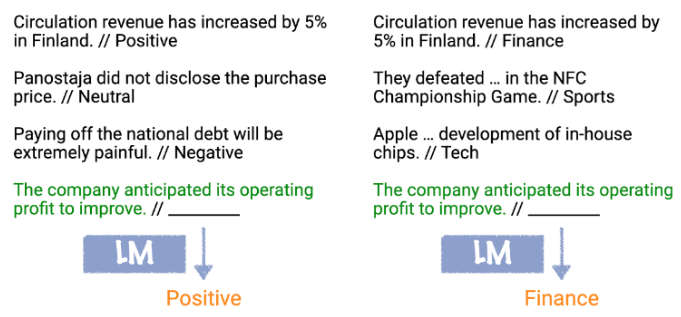

- Help LLM learn the task being asked including examples we are going to perform
- The performance of ICL depends on the quality of examples chosen in the context.
- In-context learning performs well on the models trained with labeled data
- This approach greatly reduces the cost of computation for adapting the model for new tasks and makes it possible for language-model-as-service.
- The research in understanding the mechanism and underlying reasons for LLMs to perform ICL during inference is still evolving.


**How do LLM perform ICL during inference?**

The surprising ability of GPT-3 to do in-context learning is a great success in its scope of application, but working of ICL still remains an open question. The LM learns from the examples without being explicitly pre trained to learn. But, it is unclear what enables in-context learning.

In the paper, Why can GPT learn in-context?, researchers explain language models as meta-optimizers and understand in-context learning as implicit finetuning. They figured out that Transformer attention has a dual form of gradient descent. GPT first produces meta-gradients according to the demonstration examples, and then these meta-gradients are applied to the original GPT to build an ICL model.

In the paper, An Explanation of In-context Learning as Implicit Bayesian Inference, researchers studied how in-context learning can emerge pre-training documents that have long-range coherence. The researchers provide a framework where the LM does in-context learning by using the prompt to “locate” the relevant concept it has learned during pre-training to do the task. We can theoretically view this as Bayesian inference of a latent concept conditioned on the prompt, and this capability comes from structure (long-term coherence) in the pre-training data. In contrast to messy large-scale datasets used to train LMs capable of in-context learning, researchers generate a small-scale synthetic dataset (GINC) where Transformers and LSTMs both exhibit in-context learning.

Let’s see with an example.


Large language models are surprisingly good at performing this simple task of classification and returns the correct response without the need of any examples (zero shot inference). But, if a smaller model is used then it might struggle to perform as expected although it might generate text that has some relation with the prompt.



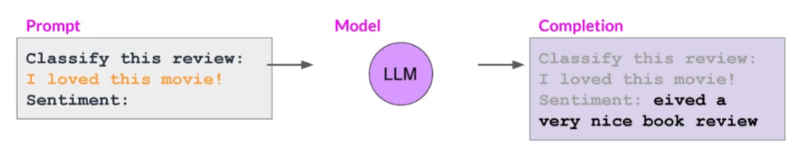

In using such a smaller LLM, which has comparatively weak understanding of language, we need to feed in some examples within the prompt so as to guide the response according to our task’s need to improve the performance.

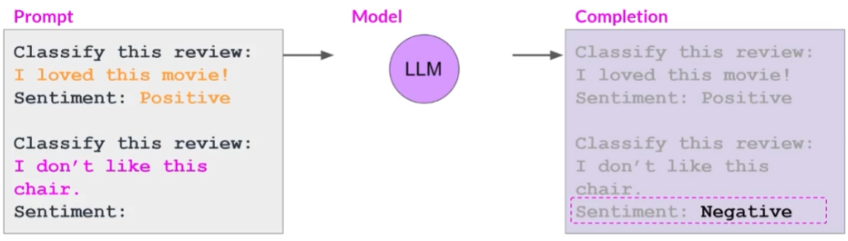

The above shown example is a one shot inference where a single example is provided via the prompt. If the task is complex, then providing a single example might not be sufficient. So, multiple examples are required to be fed in and this is known as few shot inference. For example, if an even smaller model is used then it might fail to produce good results with one example only.

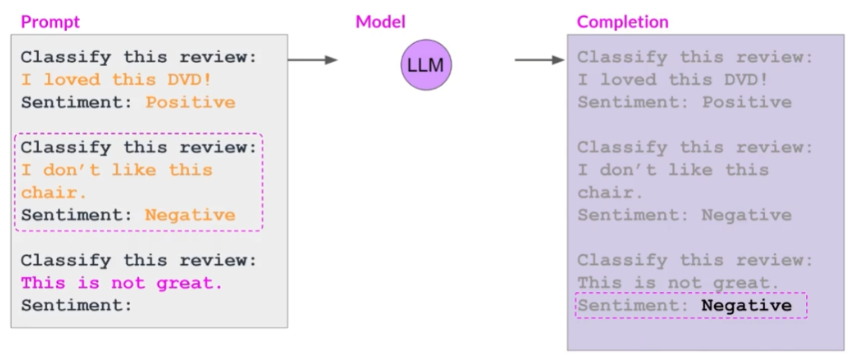

There is a limit in in-context learning with the size of the context window. We have to always keep in mind the context window of the model we are going to use before feeding in a lot of examples and making the prompt bigger than the model can take in.

As a general rule, if providing 5-6 examples in the prompt, the model is not still able to grasp the understanding of the task and does not provide the response as expected then we should opt to finetune the model or use the larger model.


#### Retrieval Augmented Generation (RAG)


Large language models suffer from several drawbacks as listed below and the RAG system helps overcome all of these challenges.

- They lack the up-to-date information as updating a large training dataset is not feasible.
- They have general knowledge of many domains and lack the domain-specific knowledge.
- They function as the black block because when we get the response we really don’t know from which source the LLM is considering that information from.
- It is inefficient and costly to produce the foundational model as it requires huge time, cost and resources.

Retrieval Augmented Generation is the process of providing the additional information retrieved from somewhere (external knowledge sources) to the user’s input that is used by a large language model to augment the response it generates.

Some of the notable features a RAG system provides are:

- The problem of hallucination of LLM makes it really difficult to trust all the response language models generated. But the use of external knowledge sources gives the model factual context to use making the response more reliable. Also, domain-specific data can be fed to the model according to the tasks.
- RAG connects the capabilities of an LLM to our data. This way the system has access to information that is always fresh and up-to-date.
- The use of the RAG system allows for the citing of the references (sources). If there is any error in those sources then they can be easily corrected or deleted.


**How Retrieval Augmented Generation works?**

The general approach for the RAG system is that when a user inputs the question then the most relevant content is searched from a knowledge base (vector database, or any other store). Then the retrieved content is used in the prompt as a context which is fed to the Large language model (LLM) for the augmented response.

At first, the knowledge base, which is a text, is converted into the vectors by using an appropriate embedding model. There are various approaches to storage of knowledge base into the vector database. We split the knowledge base into different chunk formats based on our data format in the knowledge base and the task we are going to perform.


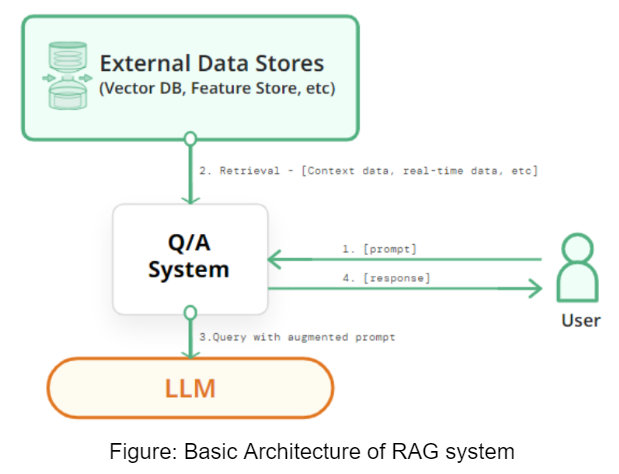

Then, a semantic search approach is used to retrieve the relevant information from the knowledge base. The quality of embedding largely affects the performance of retrieval from the database.

Then, finally the retrieved content from the knowledge base is used to supplement the prompt which is fed to the Large language model for generating the augmented response.


**Ways to improve RAG**
- Cleaning our data such that the retrieval will be a right context for the given user input. Confusing data struggle to find the correct reliable response from language models.
- Exploring the different types of index, which is an object that holds our retrieval system in a vector database.
- Finding the base embedding model for the dataset we are going to use. - - Fine Tuning our own embedding model if possible.
- Experimenting with various chunking approaches.
Trying out the meta-data filtering, hybrid searches and reranking approaches.


#### Prompting Shortcomings


- **Reasoning Errors:** Large language models have huge understanding of knowledge and can provide some reasoning capabilities when certain prompting techniques like CoT is used. But, if the language model is small and not sufficient enough to reason such that prompt with CoT is also not able to handle the task properly, then we should opt for the option of fine tuning.

- **Prompt Injection:** The world of prompting has opened up the doors for security exploits where someone can bypass the filters or manipulate the LLM using carefully crafted prompts to perform the unethical actions.

- **Locating Errors:** If there arises a situation where the response is not as expected, then the error that has occurred because of altering the prompt is hard to trace and fix.

- **Limiting the domain Knowledge:** Large language models have domain knowledge of many fields. It becomes hard if we are to control the scope of the knowledge and guide the response only based on our application. Guardrail is one of the options to this problem.
